In [2]:
from dotenv import load_dotenv
load_dotenv()

import uuid
from typing import List
from pydantic import BaseModel, Field

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage
from langchain_core.runnables import RunnableConfig
from langgraph.store.memory import InMemoryStore
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.base import BaseStore
from model import model
import uuid
from langchain_google_genai import GoogleGenerativeAIEmbeddings

embedding = GoogleGenerativeAIEmbeddings(model='gemini-embedding-001')   

In [3]:
llm = model

In [29]:
prompt = """You are a helpful assistant with memory capabilities.
If user-specific memory is available, use it to personalize 
your responses based on what you know about the user.

Your goal is to provide relevant, friendly, and tailored 
assistance that reflects the user’s preferences, context, and past interactions.

If the user’s name or relevant personal context is available, always personalize your responses by:
    – Always Address the user by name (e.g., "Sure, Nitish...") when appropriate
    – Referencing known projects, tools, or preferences (e.g., "your MCP  server python based project")
    – Adjusting the tone to feel friendly, natural, and directly aimed at the user

Avoid generic phrasing when personalization is possible. For example, instead of "In TypeScript apps..." 
say "Since your project is built with TypeScript..."

Use personalization especially in:
    – Greetings and transitions
    – Help or guidance tailored to tools and frameworks the user uses
    – Follow-up messages that continue from past context

Always ensure that personalization is based only on known user details and not assumed.

The user’s memory (which may be empty) is provided as: {user_details_content}
"""

SYSTEM_PROMPT_TEMPLATE = ChatPromptTemplate.from_messages([
    ('system', prompt),
    ("placeholder", "{messages}")])

In [ ]:
# 1. chatbot that use only the memroy not create 

In [ ]:
# suppose we have simple memorys already there into the store
store = InMemoryStore()

user_name = "Harshil"
namespace = ("user", user_name, "details")

store.put(namespace, "profile_1", {"data": "Name: Harshil Kothiya"})
store.put(namespace, "profile_2", {"data": "Profession: Associate AI/ML Engineer at Azilen Technologies"})
store.put(namespace, "preference_1", {"data": "Prefers concise, direct answers"})
store.put(namespace, "preference_2", {"data": "Likes simple explanations with examples and diagrams when applicable"})
store.put(namespace, "skill_1", {"data": "Works with Python, Machine Learning, GenAI, RAG, LangGraph and LangChain"})
store.put(namespace, "project_1", {"data": "Working on AI agent and RAG-based systems, including multi-agent applications"})

In [4]:
def chat_node(state: MessagesState, config:RunnableConfig, store:BaseStore):
    user = config['configurable']['user']

    user_namespace = ("user", user, "details")
    items = store.search(user_namespace)

    #featch all the memory 
    user_memory = "/n".join(i.value['data'] for i in items)

    print([user_memory] + state['messages'])

    res = (SYSTEM_PROMPT_TEMPLATE | llm).invoke({"user_details_content": user_memory,"messages": state["messages"]})


    return {
        "messages":[res]
    }

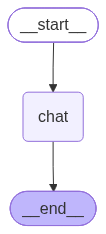

In [ ]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat_node)
builder.add_edge(START, "chat")
builder.add_edge("chat", END)

graph = builder.compile(store=store)

graph

In [ ]:
config = {"configurable": {"user": "Harshil"}}

result = graph.invoke(
    {"messages": [{"role": "user", "content": "what is my skils"}]},
    config,
)

print(result["messages"][-1].content)

['Name: Harshil Kothiya/nProfession: Associate AI/ML Engineer at Azilen Technologies/nPrefers concise, direct answers/nLikes simple explanations with examples and diagrams when applicable/nWorks with Python, Machine Learning, GenAI, RAG, LangGraph and LangChain/nWorking on AI agent and RAG-based systems, including multi-agent applications', HumanMessage(content='what is my skils', additional_kwargs={}, response_metadata={}, id='040f31c4-45b6-4ef5-86b9-a433ee367b75')]
[{'type': 'text', 'text': "Hi Harshil! Based on our past interactions, here is a summary of your skills and technical expertise:\n\n*   **Core Programming:** Python\n*   **AI & Machine Learning:** Machine Learning and Generative AI (GenAI)\n*   **Frameworks & Orchestration:** LangChain and LangGraph\n*   **Specializations:** Retrieval-Augmented Generation (RAG), AI Agents, and Multi-Agent Systems\n\nYou currently apply these skills in your role as an **Associate AI/ML Engineer at Azilen Technologies**. Let me know if you'd

In [ ]:
#2. chatbot only creat the new memorys
store = InMemoryStore()
store

In [ ]:
class MemoryDecision(BaseModel):
    should_write: bool = Field(description="Whether to store any memories")
    memories: List[str] = Field(default_factory=list, description="Atomic user memories to store")

In [ ]:
llm_memory = llm.with_structured_output(MemoryDecision)

In [5]:
def chat_creates_memory_node(state: MessagesState, config: RunnableConfig, store: BaseStore):
    
    user = config['configurable']['user']
    
    user_namespace = ("user", user, "details")

    #now we have to find the user's thinsg that we can add into the memory

    # take latest user message
    last_msg = state["messages"][-1].content

    # LLM decides what to store
    decision: MemoryDecision = llm_memory.invoke(
        [
            SystemMessage(
                content=(
                    "Extract LONG-TERM memories from the user's message.\n"
                    "Only store stable, user-specific info (identity, preferences, ongoing projects).\n"
                    "Do NOT store transient info.\n"
                    "Return should_write=false if nothing is worth storing.\n"
                    "Each memory should be a short atomic sentence."
                )
            ),
            {"role": "user", "content": last_msg},
        ]
    )


    # if memeory avalible then add it 
    if decision.should_write:
        for mem in decision.memories:
            store.put(user_namespace, str(uuid.uuid4()), {'data':mem})

    return {"messages": [{"role": "assistant", "content": "Noted."}]}

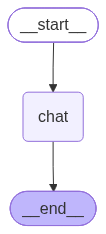

In [ ]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat_creates_memory_node)
builder.add_edge(START, "chat")
builder.add_edge("chat", END)

graph = builder.compile(store=store)
graph

In [ ]:
config

{'configurable': {'user': 'Harshil'}}

In [ ]:
r1 = graph.invoke({"messages": [{"role": "user", "content": "My name is Harshil"}]}, config)
print("\nAssistant:", r1["messages"][-1].content)


Assistant: Noted.


In [ ]:
r2 = graph.invoke({"messages": [{"role": "user", "content": "I like Python for programming."}]}, config)
print("\nAssistant:", r2["messages"][-1].content)

r3 = graph.invoke({"messages": [{"role": "user", "content": "My name is Harshil"}]}, config)
print("\nAssistant:", r3["messages"][-1].content)


Assistant: Noted.

Assistant: Noted.


In [ ]:
store.search(("user", "Harshil", "details"))

[Item(namespace=['user', 'Harshil', 'details'], key='386ffe5b-a57a-4355-b9c8-cffdee0fe99d', value={'data': "The user's name is Harshil"}, created_at='2026-09-30T18:18:56.075856+00:00', updated_at='2026-09-30T18:18:56.075856+00:00', score=None),
 Item(namespace=['user', 'Harshil', 'details'], key='3c0539d9-5bce-4063-8f09-a0a5087c2dd8', value={'data': 'The user prefers Python for programming.'}, created_at='2026-09-30T18:19:01.201734+00:00', updated_at='2026-09-30T18:19:01.201734+00:00', score=None),
 Item(namespace=['user', 'Harshil', 'details'], key='f340118a-cb46-44c3-abb7-299e3c033421', value={'data': "The user's name is Harshil"}, created_at='2026-09-30T18:19:05.451859+00:00', updated_at='2026-09-30T18:19:05.451859+00:00', score=None)]

In [6]:
# 3. chatbot can use memeory and creat distinct memorys
store = InMemoryStore()

In [7]:
class MemoryItem(BaseModel):
    text: str = Field(description="Atomic user memory as a short sentence")
    is_new: bool = Field(description="True if this memory is NEW and should be stored. False if duplicate/already known.")

In [8]:
class MemoryDecision(BaseModel):
    should_write: bool = Field(description="Whether to store any memories")
    memories: List[MemoryItem] = Field(default_factory=list, description="Atomic user memories to store")

In [9]:
llm_memory = llm.with_structured_output(MemoryDecision)

In [10]:
MEMORY_PROMPT = """You are responsible for updating and maintaining accurate user memory.

CURRENT USER DETAILS (existing memories):
{user_details_content}

TASK:
- Review the user's latest message.
- Extract user-specific info worth storing long-term (identity, stable preferences, ongoing projects/goals).
- For each extracted item, set is_new=true ONLY if it adds NEW information compared to CURRENT USER DETAILS.
- If it is basically the same meaning as something already present, set is_new=false.
- Keep each memory as a short atomic sentence.
- No speculation; only facts stated by the user.
- If there is nothing memory-worthy, return an empty list.
"""

In [11]:
def chat_creates_memory_node(state: MessagesState, config: RunnableConfig, store: BaseStore):

    user_id = config["configurable"]["user"]

    namespace = ("user", user_id, "details")

    # A) Load existing memories
    existing_items = store.search(namespace)
    existing_texts = [it.value.get("data", "") for it in existing_items if it.value.get("data")]
    user_details_content = "\n".join(f"- {t}" for t in existing_texts) if existing_texts else "(empty)"

    # B) Latest user message
    last_text = state["messages"][-1]

    # C) LLM extracts memories + marks new vs duplicate
    decision: MemoryDecision = llm_memory.invoke(
        [
            SystemMessage(content=MEMORY_PROMPT.format(user_details_content=user_details_content)),
            {"role": "user", "content": f"USER MESSAGE:\n{last_text}"},
        ]
    )

    # D) Store ONLY new memories
    if decision.should_write:
        for mem in decision.memories:
            if mem.is_new:
                store.put(namespace, str(uuid.uuid4()), {"data": mem.text})

    return {"messages": [{"role": "assistant", "content": "Noted."}]}

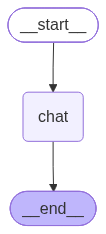

In [12]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat_creates_memory_node)
builder.add_edge(START, "chat")
builder.add_edge("chat", END)

graph = builder.compile(store=store)
graph

In [14]:
config = {"configurable": {"user": "Harshil"}}

In [15]:
r1 = graph.invoke({"messages": [{"role": "user", "content": "My name is Harshil"}]}, config)
print("\nAssistant:", r1["messages"][-1].content)

r2 = graph.invoke({"messages": [{"role": "user", "content": "I like Python for programming."}]}, config)
print("\nAssistant:", r2["messages"][-1].content)

r3 = graph.invoke({"messages": [{"role": "user", "content": "My name is Harshil"}]}, config)
print("\nAssistant:", r3["messages"][-1].content)

store.search(("user", "Harshil", "details"))

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.



Assistant: Noted.

Assistant: Noted.

Assistant: Noted.


[Item(namespace=['user', 'Harshil', 'details'], key='3c50a394-e1e0-4deb-8e60-d3ab357aa234', value={'data': "The user's name is Harshil."}, created_at='2026-10-01T17:34:48.631225+00:00', updated_at='2026-10-01T17:34:48.631225+00:00', score=None),
 Item(namespace=['user', 'Harshil', 'details'], key='15575557-061b-46a5-8f9d-3bd75f3f77aa', value={'data': 'The user likes Python for programming.'}, created_at='2026-10-01T17:34:51.087300+00:00', updated_at='2026-10-01T17:34:51.087300+00:00', score=None)]

In [16]:
#4 make the end to end chatbot -> that can create non-dublicate memory and use it 

In [30]:
store = InMemoryStore()

In [31]:
#chat node
def chat_node(state: MessagesState, config:RunnableConfig, store:BaseStore):
    user = config['configurable']['user']

    user_namespace = ("user", user, "details")
    items = store.search(user_namespace)

    #featch all the memory 
    user_memory = "/n".join(i.value['data'] for i in items)

    print([user_memory] + state['messages'])

    res = (SYSTEM_PROMPT_TEMPLATE | llm).invoke({"user_details_content": user_memory,"messages": state["messages"]})


    return {
        "messages":[res]
    }

In [32]:
#memory node
class MemoryItem(BaseModel):
    text: str = Field(description="Atomic user memory as a short sentence")
    is_new: bool = Field(description="True if this memory is NEW and should be stored. False if duplicate/already known.")

class MemoryDecision(BaseModel):
    should_write: bool = Field(description="Whether to store any memories")
    memories: List[MemoryItem] = Field(default_factory=list, description="Atomic user memories to store")


llm_memory = llm.with_structured_output(MemoryDecision)


MEMORY_PROMPT = """You are responsible for updating and maintaining accurate user memory.

CURRENT USER DETAILS (existing memories):
{user_details_content}

TASK:
- Review the user's latest message.
- Extract user-specific info worth storing long-term (identity, stable preferences, ongoing projects/goals).
- For each extracted item, set is_new=true ONLY if it adds NEW information compared to CURRENT USER DETAILS.
- If it is basically the same meaning as something already present, set is_new=false.
- Keep each memory as a short atomic sentence.
- No speculation; only facts stated by the user.
- If there is nothing memory-worthy, return an empty list.
"""

In [33]:
def chat_creates_memory_node(state: MessagesState, config: RunnableConfig, store: BaseStore):

    user_id = config["configurable"]["user"]

    namespace = ("user", user_id, "details")

    # A) Load existing memories
    existing_items = store.search(namespace)
    existing_texts = [it.value.get("data", "") for it in existing_items if it.value.get("data")]
    user_details_content = "\n".join(f"- {t}" for t in existing_texts) if existing_texts else "(empty)"

    # B) Latest user message
    last_text = state["messages"][-1]

    # C) LLM extracts memories + marks new vs duplicate
    decision: MemoryDecision = llm_memory.invoke(
        [
            SystemMessage(content=MEMORY_PROMPT.format(user_details_content=user_details_content)),
            {"role": "user", "content": f"USER MESSAGE:\n{last_text}"},
        ]
    )

    # D) Store ONLY new memories
    if decision.should_write:
        for mem in decision.memories:
            if mem.is_new:
                store.put(namespace, str(uuid.uuid4()), {"data": mem.text})

    return {"messages": [{"role": "assistant", "content": "Noted."}]}

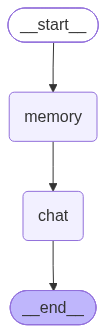

In [34]:
g = StateGraph(MessagesState)
g.add_node('chat', chat_node)
g.add_node('memory', chat_creates_memory_node)

g.add_edge(START, "memory")
g.add_edge('memory', 'chat')
g.add_edge("chat", END)

graph = g.compile(store=store)

graph

In [68]:
# config = {'configurable':{"user":"Harshil"}}
config = {'configurable':{"user":"Kothiya"}}

In [69]:
res = graph.invoke({"messages":[{'role':'user', "content":"my name is KOthiya"}]}, config=config)

["The user's name is KOthiya.", HumanMessage(content='my name is KOthiya', additional_kwargs={}, response_metadata={}, id='5e0aed2e-6fc7-4bcc-8a61-99aee1f66672'), AIMessage(content='Noted.', additional_kwargs={}, response_metadata={}, id='19afad0d-2430-444e-a221-cbfa7af5ce05', tool_calls=[], invalid_tool_calls=[])]


In [ ]:
res = graph.invoke({"messages":[{'role':'user', "content":"can you tell me what is my name ? "}]}, config=config)


In [ ]:
res['messages']

[HumanMessage(content='can you tell me what i love and  give me answer in always one word', additional_kwargs={}, response_metadata={}, id='8eb9e4f7-83dc-4817-8c99-bd0f120d1a4c'),
 AIMessage(content='Noted.', additional_kwargs={}, response_metadata={}, id='21b14a73-5085-491a-b16b-f00bde19c7af', tool_calls=[], invalid_tool_calls=[]),
 AIMessage(content=[{'type': 'text', 'text': ' I will keep my answer to exactly one word.\n\nPizza.'}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0f897-0135-7283-8600-71c07696f5c6-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 288, 'output_tokens': 13, 'total_tokens': 301, 'input_token_details': {'cache_read': 0}})]

In [72]:
namespace = ("user", "Kothiya", "details")
store.search(namespace)

[Item(namespace=['user', 'Kothiya', 'details'], key='97e86481-80ee-430d-9482-7e1aba1af290', value={'data': "The user's name is KOthiya."}, created_at='2026-10-01T17:51:33.553664+00:00', updated_at='2026-10-01T17:51:33.553664+00:00', score=None)]